<a href="https://colab.research.google.com/github/kikijamal/SemProject_MLEngine/blob/main/NEU_Metal_Surface_Defects_Dataset_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write('{"username":"your_kaggle_username","key":"KGAT_79a744e68e6f7f7ae5fe2723b388e175"}')

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

print("Kaggle configured successfully")

Kaggle configured successfully


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (2).zip


In [ ]:
import zipfile
import os

for filename in uploaded.keys():
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('/content/neu_dataset')
    print(f"Extracted {filename} successfully")

print("\nContents:")
for item in os.listdir('/content/neu_dataset'):
    print(item)

Extracted archive (2).zip successfully

Contents:
NEU-DET


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported")

Libraries imported


In [ ]:
dataset_path = '/content/neu_dataset'
image_data = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            folder_name = os.path.basename(root)
            file_path = os.path.join(root, file)
            file_size = os.path.getsize(file_path)
            image_data.append({
                'filename': file,
                'class_label': folder_name,
                'file_path': file_path,
                'file_size_bytes': file_size,
                'file_extension': os.path.splitext(file)[1].lower()
            })

df = pd.DataFrame(image_data)
print(f"Dataframe created with {len(df)} records")
df.head()

Dataframe created with 1800 records


,filename,class_label,file_path,file_size_bytes,file_extension
0,crazing_68.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,20155,.jpg
1,crazing_85.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,19709,.jpg
2,crazing_60.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,20134,.jpg
3,crazing_40.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,22583,.jpg
4,crazing_197.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,23686,.jpg


In [ ]:
rows, columns = df.shape
print("QUESTION A: Dataset Dimensions")
print(f"Number of rows    : {rows}")
print(f"Number of columns : {columns}")
print()
print("Class distribution:")
print(df['class_label'].value_counts())

QUESTION A: Dataset Dimensions
Number of rows    : 1800
Number of columns : 5

Class distribution:
class_label
crazing            300
rolled-in_scale    300
patches            300
scratches          300
pitted_surface     300
inclusion          300
Name: count, dtype: int64


In [ ]:
print("QUESTION B: Data Types")
print()
print(df.dtypes)
print()
df.info()

QUESTION B: Data Types

filename           object
class_label        object
file_path          object
file_size_bytes     int64
file_extension     object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   filename         1800 non-null   object
 1   class_label      1800 non-null   object
 2   file_path        1800 non-null   object
 3   file_size_bytes  1800 non-null   int64 
 4   file_extension   1800 non-null   object
dtypes: int64(1), object(4)
memory usage: 70.4+ KB


In [ ]:
print("QUESTION C: Dataset Completeness")
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Total missing values: {df.isnull().sum().sum()}")
print()
if df.isnull().sum().sum() == 0:
    print("RESULT: Dataset is COMPLETE — no missing values found.")
else:
    print("RESULT: Dataset has MISSING VALUES.")

QUESTION C: Dataset Completeness

Missing values per column:
filename           0
class_label        0
file_path          0
file_size_bytes    0
file_extension     0
dtype: int64

Total missing values: 0

RESULT: Dataset is COMPLETE — no missing values found.


In [ ]:
first_15 = df.head(15)
last_20 = df.tail(20)

df_sample = pd.concat([first_15, last_20], ignore_index=True)

print(f"First 15 rows shape: {first_15.shape}")
print(f"Last 20 rows shape: {last_20.shape}")
print(f"df_sample shape: {df_sample.shape}")

First 15 rows shape: (15, 5)
Last 20 rows shape: (20, 5)
df_sample shape: (35, 5)


In [ ]:
df_sample

,filename,class_label,file_path,file_size_bytes,file_extension
0,crazing_68.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,20155,.jpg
1,crazing_85.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,19709,.jpg
2,crazing_60.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,20134,.jpg
3,crazing_40.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,22583,.jpg
4,crazing_197.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,23686,.jpg
5,crazing_37.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,20107,.jpg
6,crazing_98.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,22546,.jpg
7,crazing_191.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,23758,.jpg
8,crazing_192.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,23715,.jpg
9,crazing_55.jpg,crazing,/content/neu_dataset/NEU-DET/train/images/craz...,20186,.jpg


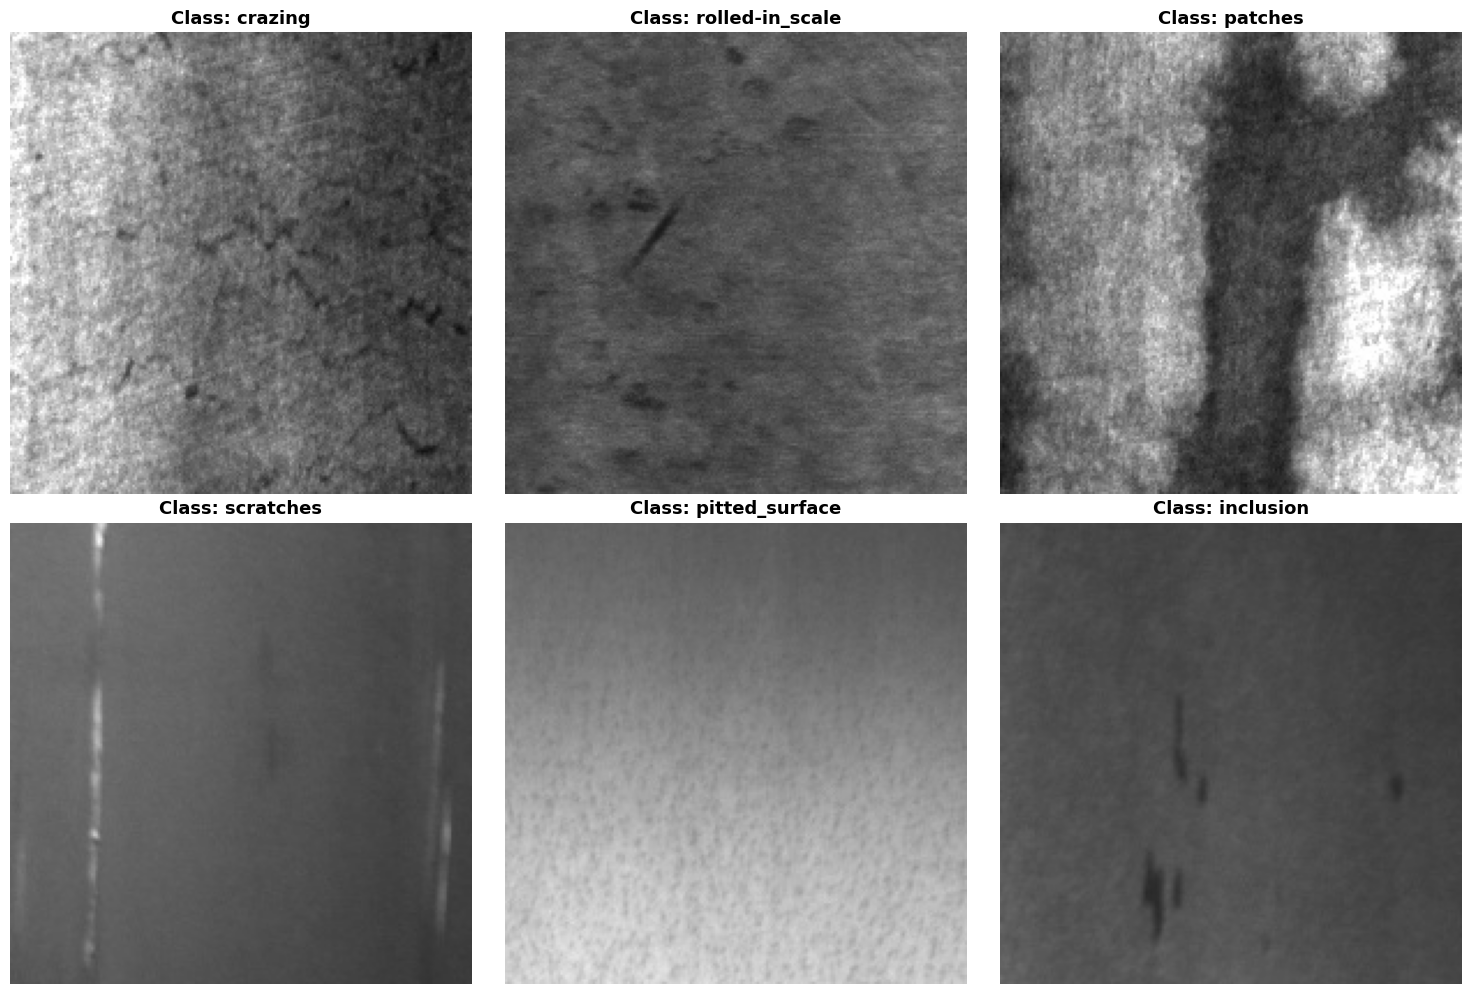

In [ ]:
classes = df['class_label'].unique()
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    sample_image_path = df[df['class_label'] == cls].iloc[0]['file_path']
    img = mpimg.imread(sample_image_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Class: {cls}', fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()